In [ ]:
import notebook_setup
import matplotlib.pyplot as plt
import numpy as np
import json
from matplotlib.ticker import ScalarFormatter

from src.plot_style import set_plot_style
from plot_utils import create_figure
from plot_config import get_colors, get_marker

set_plot_style()

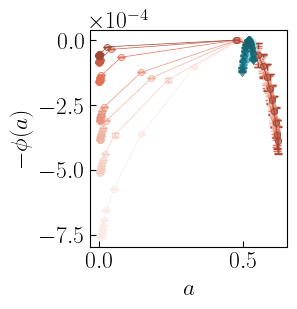

In [ ]:
fig, ax = create_figure(5.0, 5.5, margin_cm=2.0)

with open("figures_data/rate_function_data.json", "r") as f:
    data = json.load(f)

num_sites_range = np.array([4, 6, 8, 10, 20, 40, 60])
V_values = np.array([5.875, 2.0])

for n, L in enumerate(num_sites_range):
    for V in V_values:
        activity_values = data[f"activity_V_{V}_L_{L}"]
        phi_values = data[f"phi_V_{V}_L_{L}"]
        error_values = data[f"errors_V_{V}_L_{L}"]
        colors_soft = get_colors(V, alpha=0.3)
        marker = get_marker(V)
        ax.plot(activity_values, phi_values, marker=marker, markersize=4.5, markeredgewidth=0.5, lw=0.5, c=colors[n], markerfacecolor=colors_soft[n], markeredgecolor=colors[n])
        ax.errorbar(activity_values, phi_values, yerr=error_values, linestyle='None', capsize=3, elinewidth=1, zorder=1, c=colors[n])

ax.set_xlabel(r"$a$", fontsize=17)
ax.set_ylabel(r"$-\phi(a)$", fontsize=17)
ax.tick_params(axis='x', labelsize=17)
ax.tick_params(axis='y', labelsize=17)

sf = ScalarFormatter(useMathText=True)
sf.set_powerlimits((0,0))
ax.yaxis.set_major_formatter(sf)
ax.yaxis.offsetText.set_fontsize(17)

plt.savefig("figures/svg/fig3_c.svg", dpi=300, transparent=True)
plt.savefig("figures/pdf/fig3_c.pdf", dpi=300, transparent=True)
plt.show()